# Analysing morphological properties of different celltypes from a xenium experiment

In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
adata

AnnData object with n_obs × n_vars = 193025 × 5056
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'compartment', 'shape_index', 'solidity', 'replicate', 'condition', 'batch_key', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden', 'highlight', 'leiden_0.5', 'leiden_0.65', 'leiden_0.75', 'leiden_0.85', 'leiden_1.0', 'mac_subcluster', '3_subcluster', 'celltype_assignments', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter'
    var: 'gene_ids', 'feature_types', 'genome', 'me

In [33]:
mask = adata.obs['celltype_assignments'] == 'macrophage'
mask.sum()

np.int64(0)

## Defining graphing functions

In [52]:
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np

def compare_average(celltypes, property, adata):
    data = []
    for celltype in celltypes:
        data.append(adata.obs[adata.obs['celltype_assignments'] == celltype][property].dropna().values)

    # Scale figure width with number of celltypes
    fig, ax = plt.subplots(figsize=(len(celltypes) * 0.8, 6))

    bp = ax.boxplot(data, patch_artist=True, labels=celltypes)

    # Use a colormap that supports arbitrary numbers of colors
    colors = [cm.tab20(i / len(celltypes)) for i in range(len(celltypes))]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_xlabel('Cell Type')
    ax.set_ylabel(property.replace('_', ' ').title())
    ax.set_title(f'Comparison of {property.replace("_", " ").title()} Between Cell Types')

    # Rotate x labels so they don't overlap
    ax.set_xticklabels(celltypes, rotation=45, ha='right')

    legend_handles = [
        mpatches.Patch(color=colors[i], label=celltypes[i])
        for i in range(len(celltypes))
    ]
    ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()


C:\Users\dbuxton\AppData\Local\Temp\ipykernel_16712\1923466174.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = data.groupby(group_by)[morph_props].median()


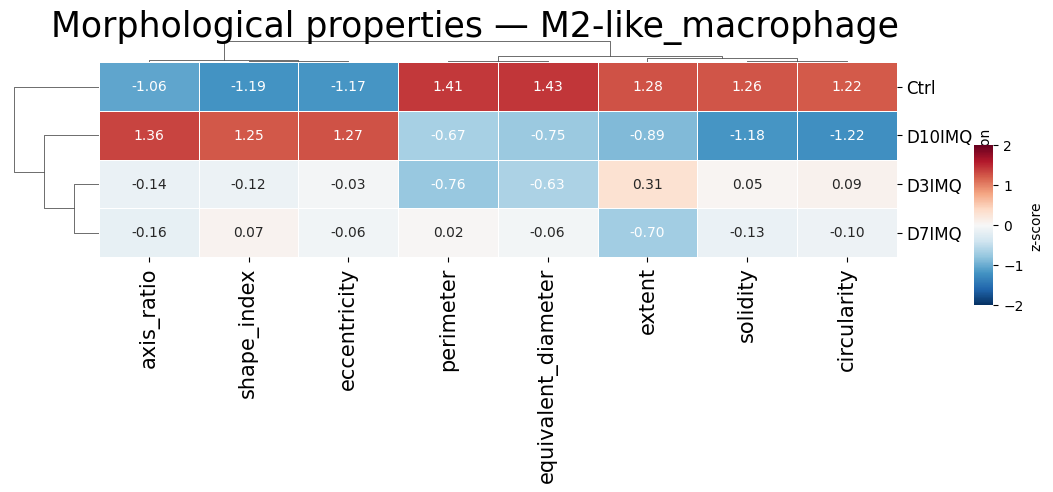

In [76]:
# Cluster map for a given celltype, comparing all properties across samples

#Cluster map of median of features vs sample for a given celltype
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

morph_props = ['shape_index', 'solidity', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter']

def morph_heatmap(adata, celltype, group_by):
    """
    group_by is the sample grouping to use, either condition (course) or batch_key (fine)
    """
    data = adata.obs[adata.obs['celltype_assignments'] == celltype]

    # mean per sample per property
    mean_df = data.groupby(group_by)[morph_props].median()

    # min-max normalise each property independently (column-wise)
    norm_df = (mean_df - mean_df.mean()) / mean_df.std()

    g = sns.clustermap(norm_df, cmap='RdBu_r', annot=True, fmt='.2f',
                linewidths=0.5, 
                cbar_kws={'label': 'z-score'},
                dendrogram_ratio=0.1,
                cbar_pos =(1.02, 0.3, 0.02, 0.4),
                figsize = (len(morph_props)*1.2, len(norm_df)*1.0))
    
    g.ax_heatmap.collections[0].set_clim(-2, 2)
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=15)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=12, rotation=0)
    
    g.fig.suptitle(f'Morphological properties — {celltype}', fontsize = 25, y=1.04)
    plt.show()


morph_heatmap(adata, 'M2-like_macrophage', group_by = 'condition')

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_16712\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


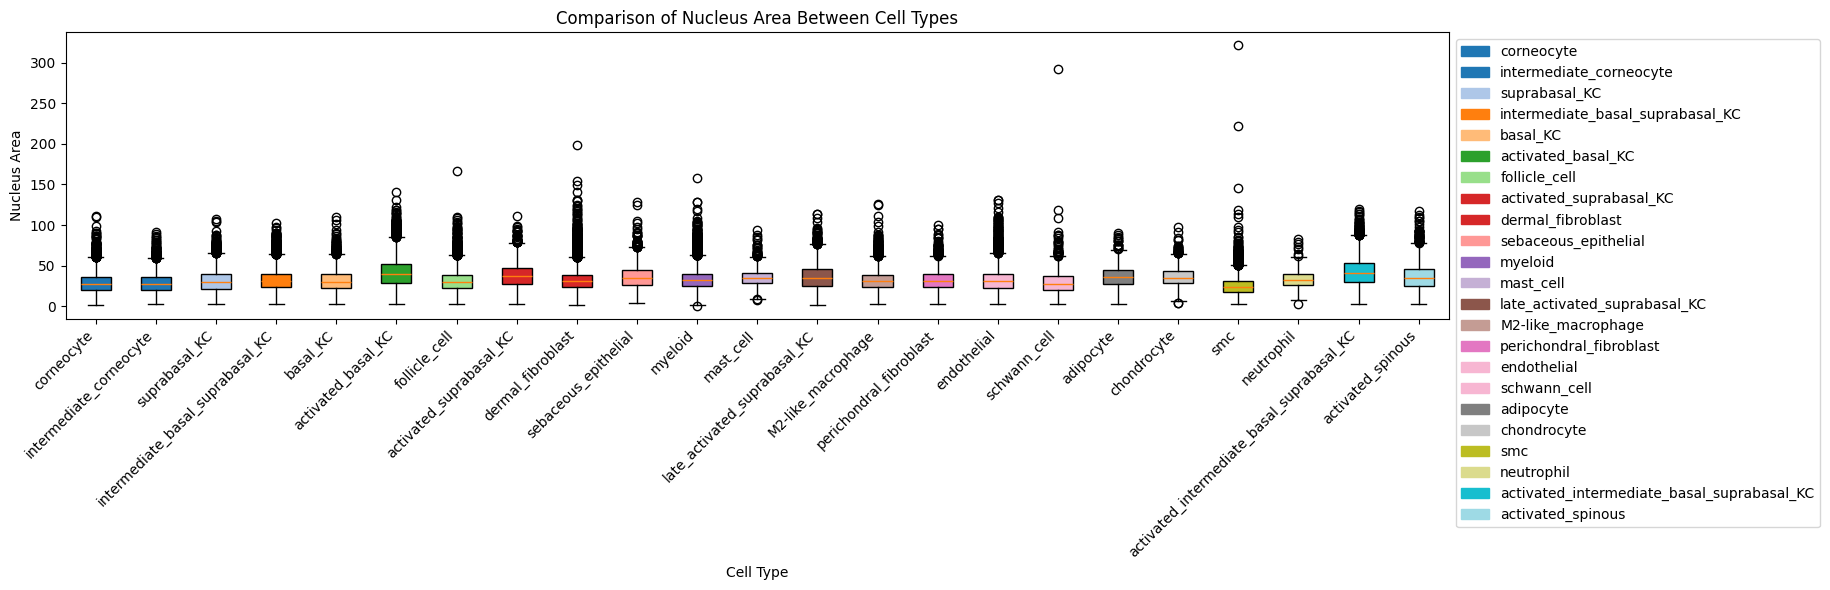

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_16712\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


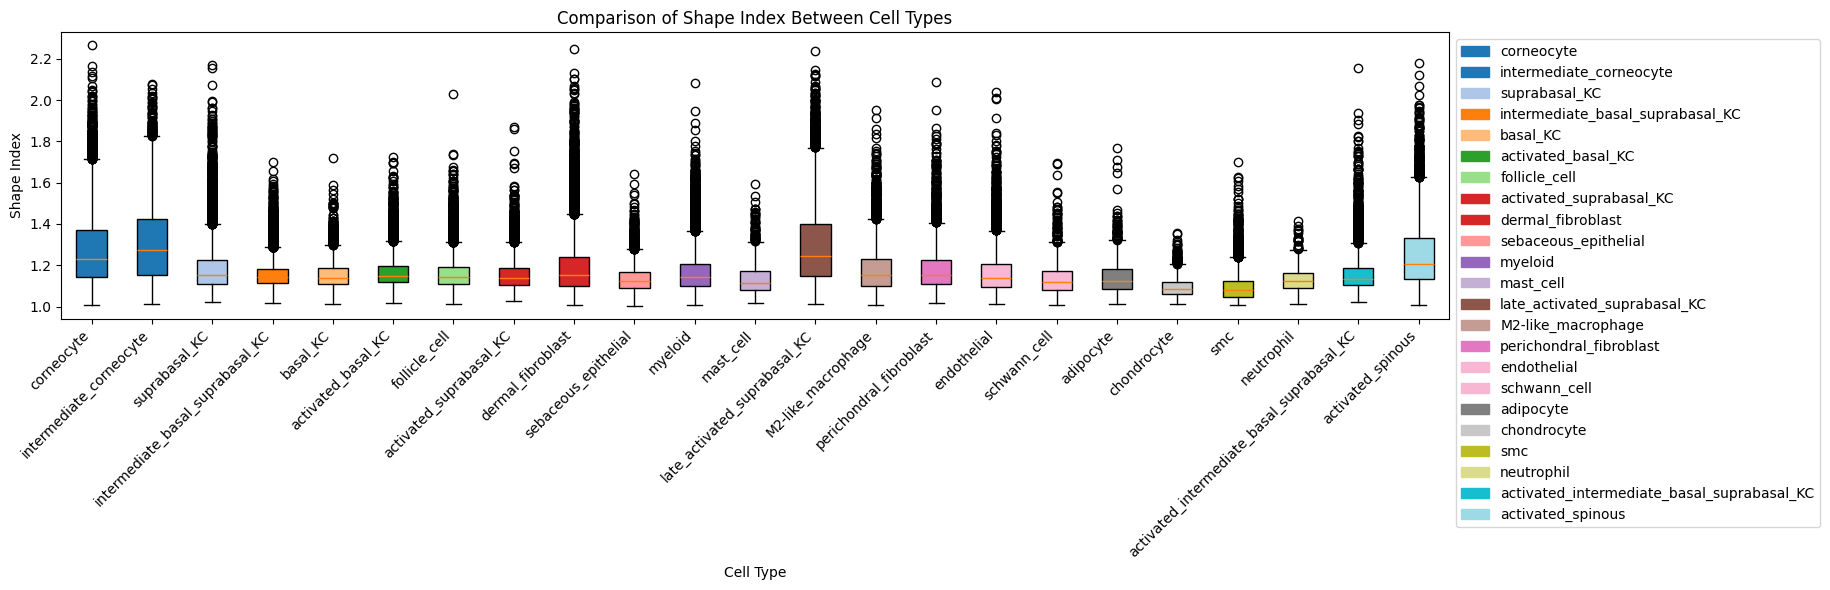

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_16712\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


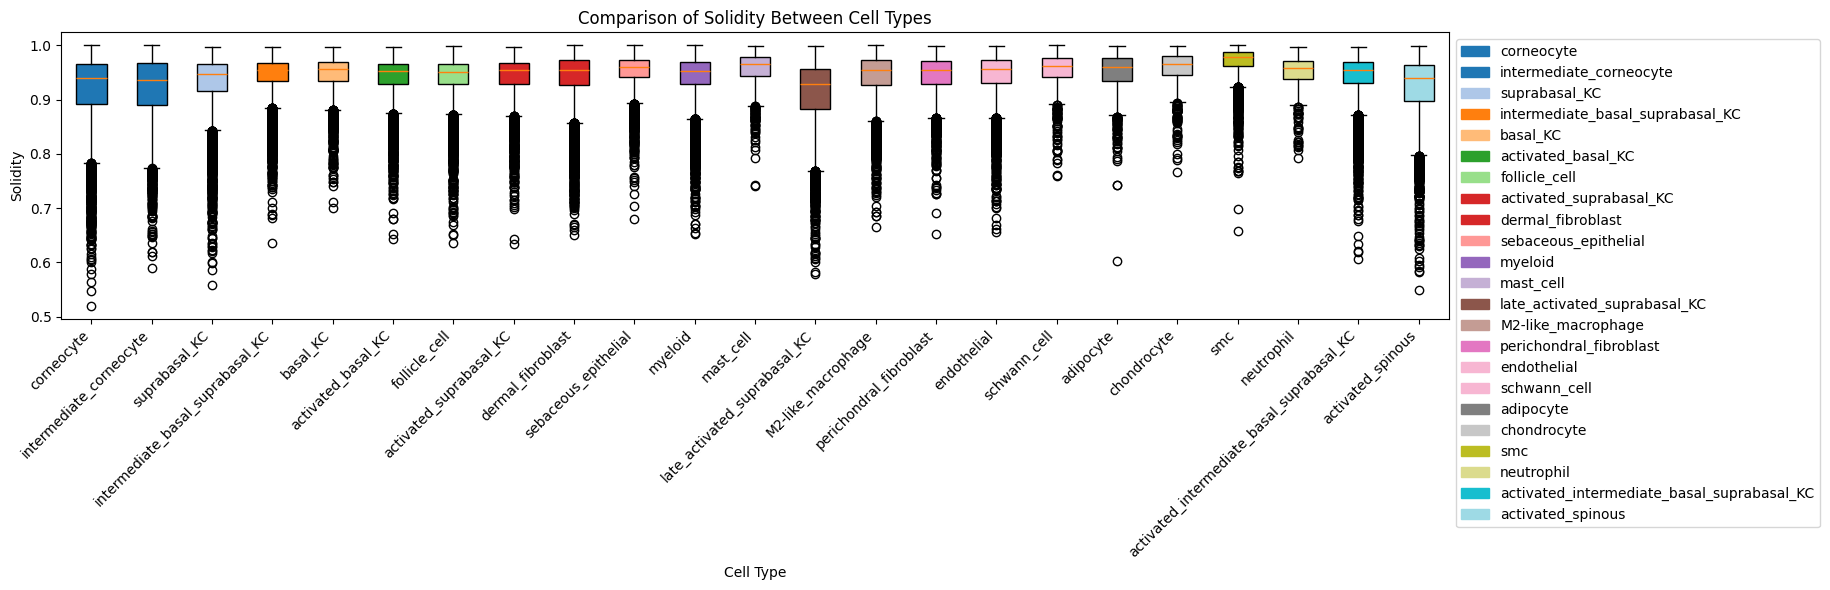

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_16712\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


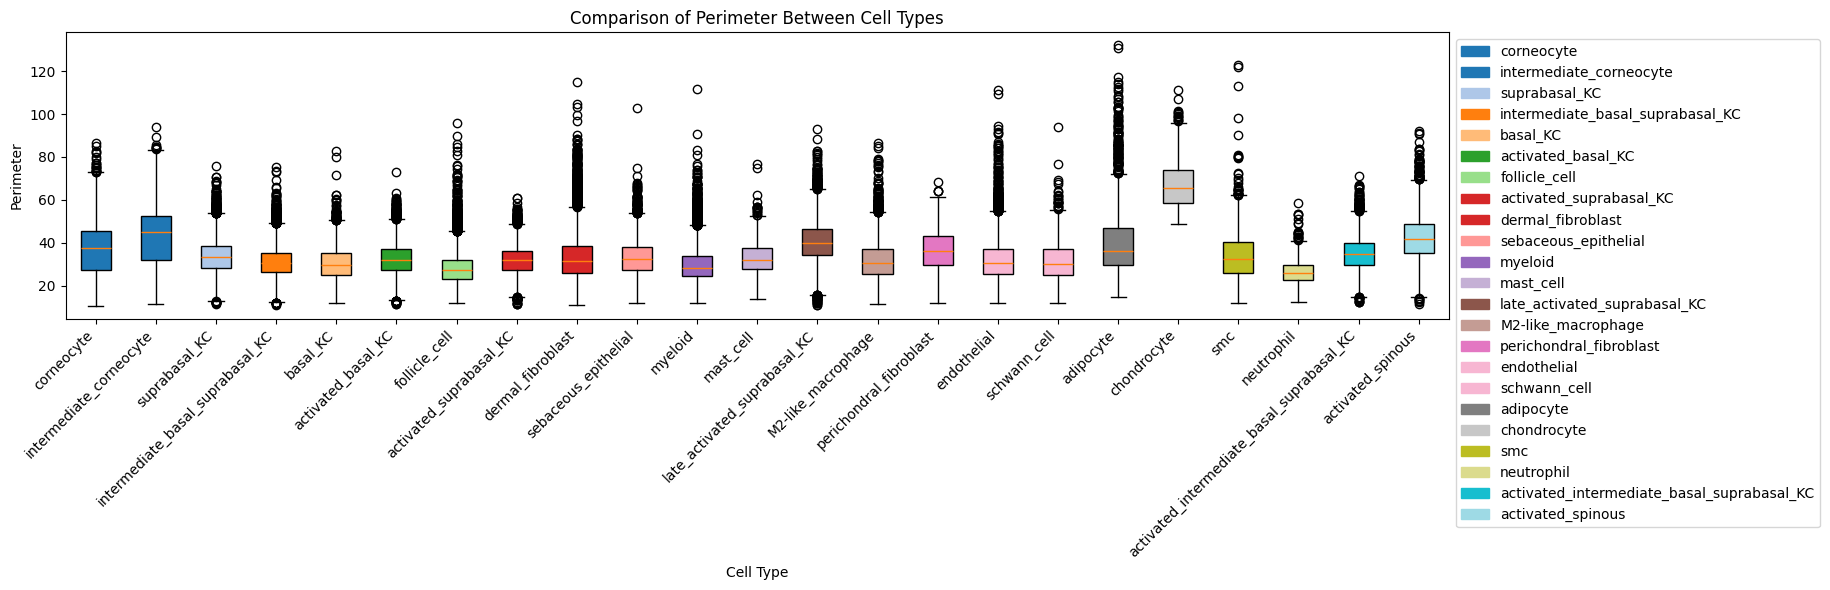

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_16712\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


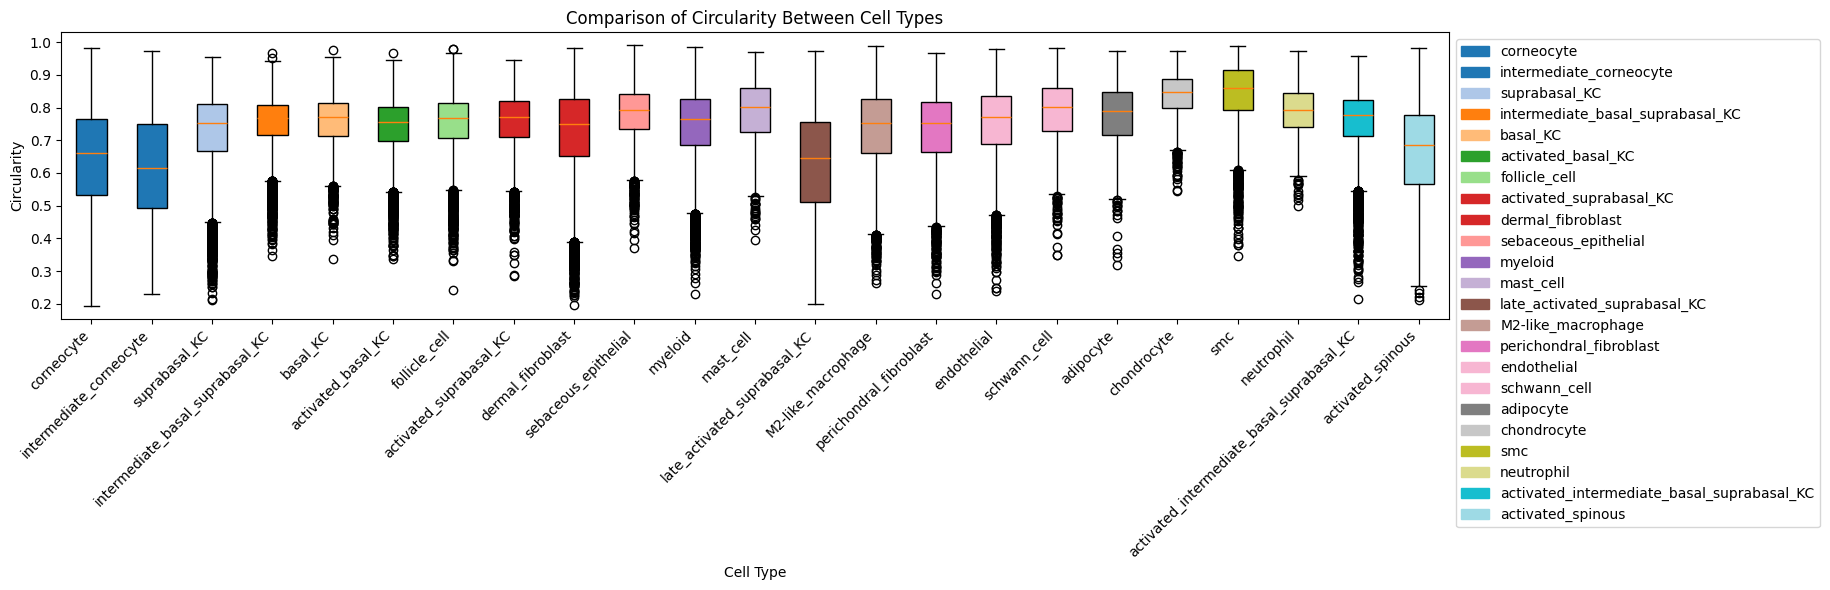

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_16712\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


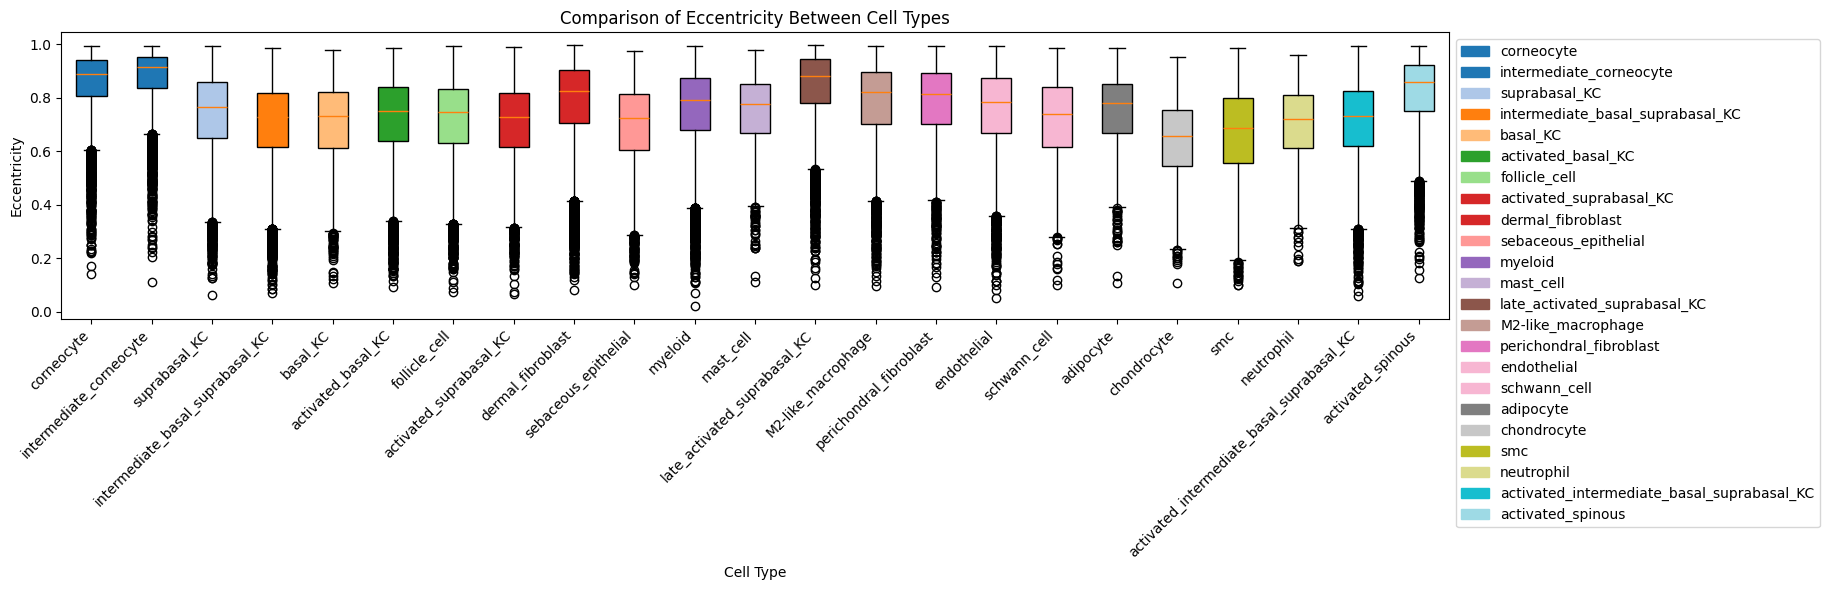

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_16712\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


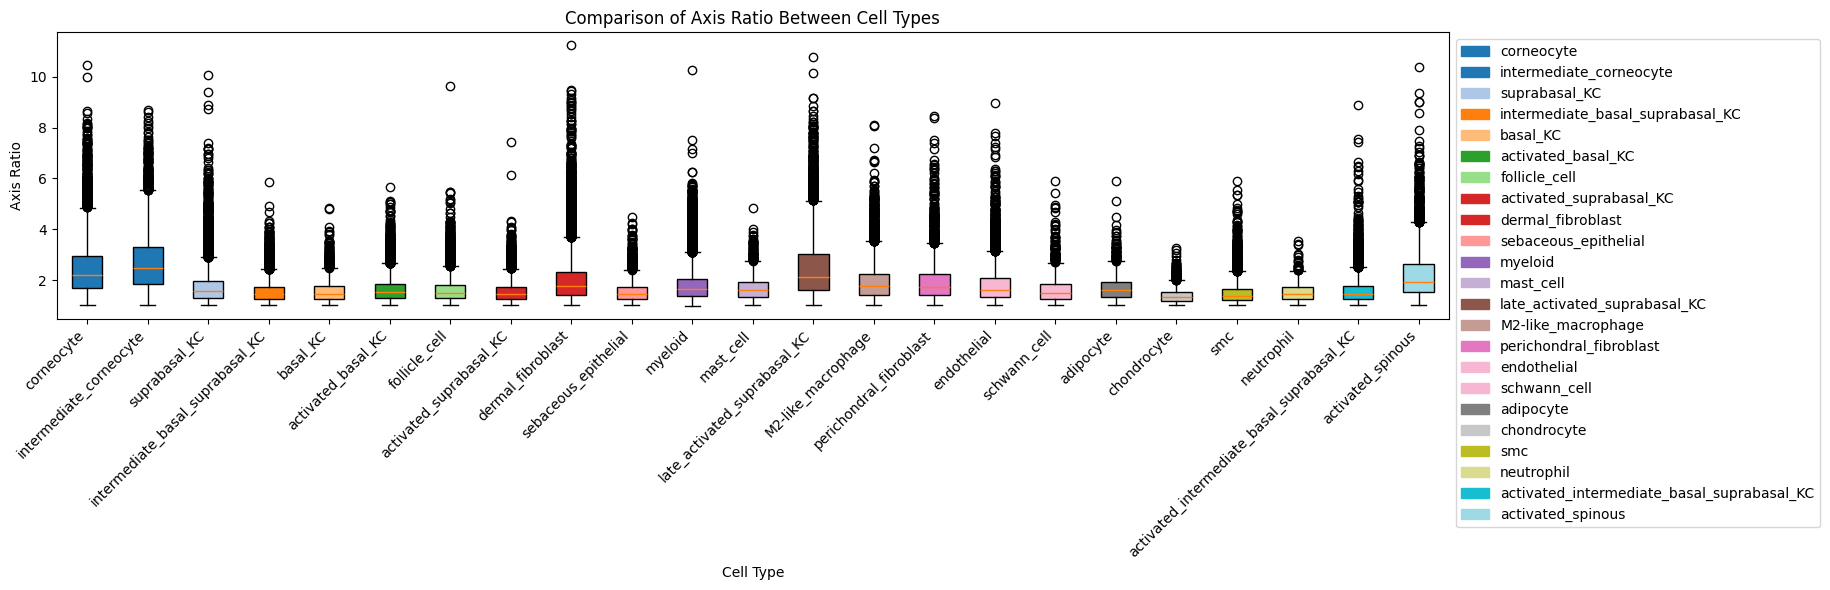

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_16712\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


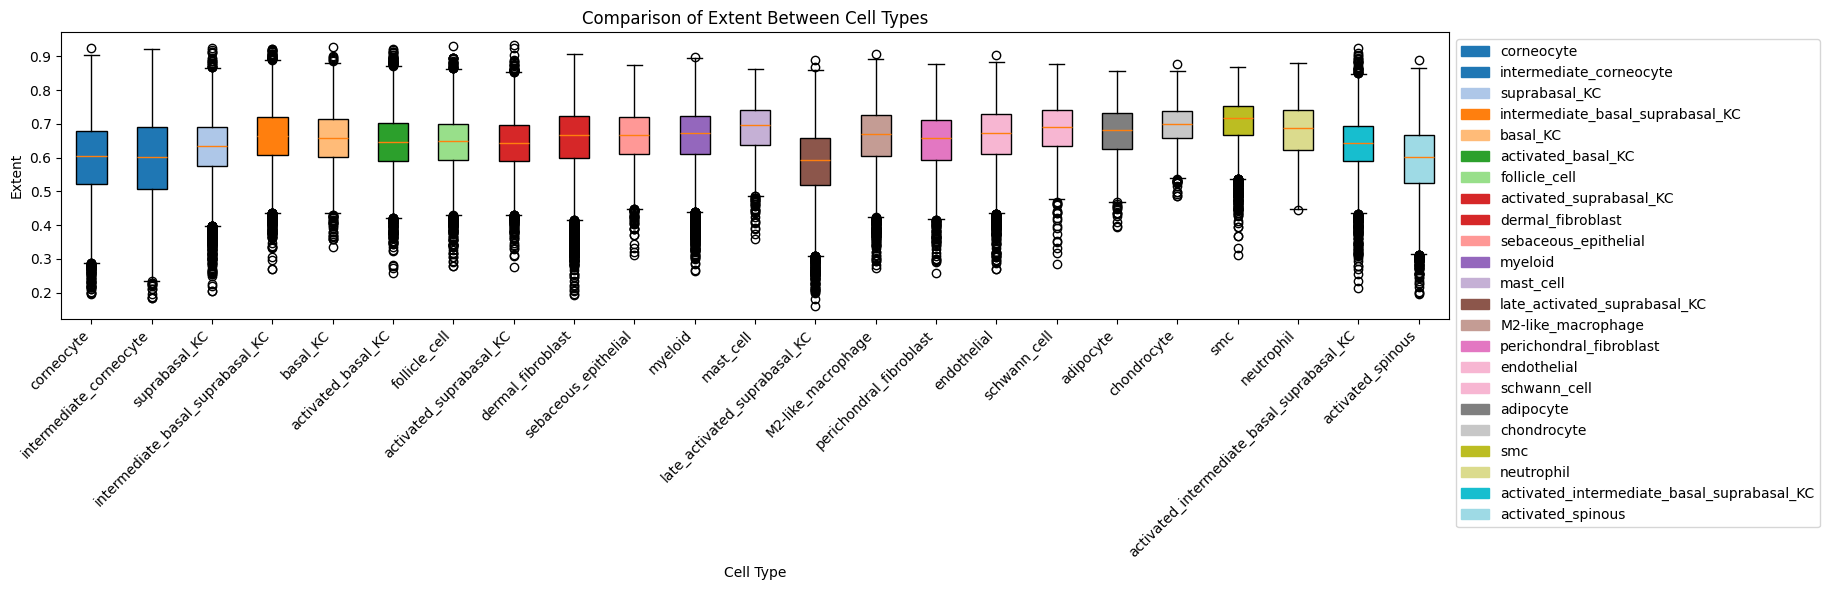

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_16712\3266480246.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=celltypes)


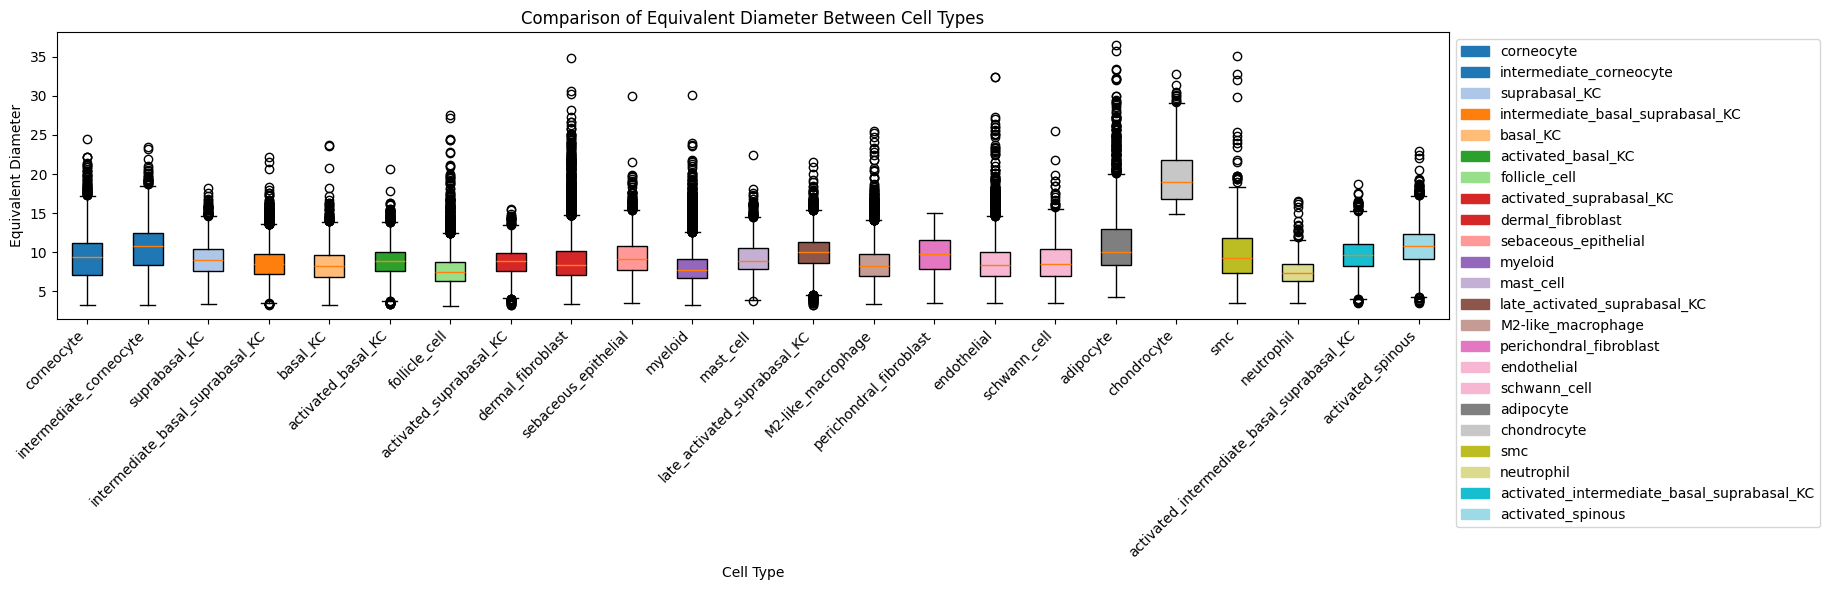

In [53]:
for property in ['nucleus_area', 'shape_index', 'solidity', 'perimeter', 'circularity', 'eccentricity', 'axis_ratio', 'extent', 'equivalent_diameter']:
    compare_average(celltypes=['corneocyte',
    'intermediate_corneocyte',
    'suprabasal_KC',
    'intermediate_basal_suprabasal_KC',
    'basal_KC',
    'activated_basal_KC',
    'follicle_cell',
    'activated_suprabasal_KC',
    'dermal_fibroblast',
    'sebaceous_epithelial',
    'myeloid',
    'mast_cell',
    'late_activated_suprabasal_KC',
    'M2-like_macrophage',
    'perichondral_fibroblast',
    'endothelial',
    'schwann_cell',
    'adipocyte',
    'chondrocyte',
    'smc',
    'neutrophil',
    'activated_intermediate_basal_suprabasal_KC',
    'activated_spinous'], property = property, adata = adata)